# HRDPS-subsampled-Driven Results in March, Jun, September and December



## SST

### SST Map in each month

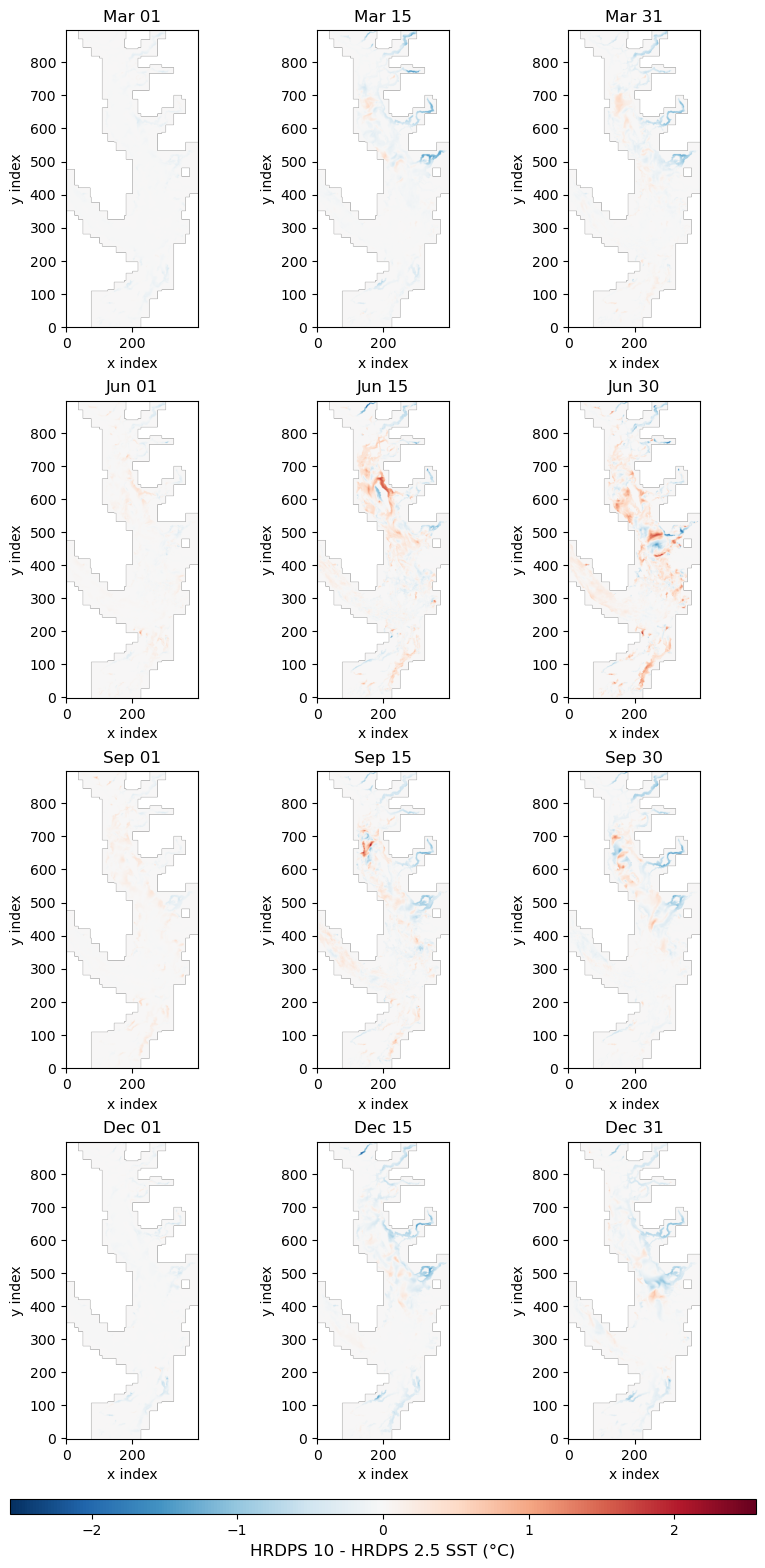

In [1]:
# SST diff in Mar, Jun, Sep and Dec

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# CaSR monthly grid_T paths -> HRDPS 10 
# Variable names unchanged, but path and printings change
# ============================================================
path_CaSR_mar_t = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_CaSR_jun_t = (
    '/ocean/jqiu/results/Flux/flux_00jun23_hrdps10/'
    'SalishSea_1d_20230601_20230630_grid_T.nc'
)

path_CaSR_sep_t = (
    '/ocean/jqiu/results/Flux/flux_00sep23_hrdps10/'
    'SalishSea_1d_20230901_20230930_grid_T.nc'
)

# December CaSR 
path_CaSR_dec_t = (
    '/ocean/jqiu/results/Flux/flux_00dec23_hrdps10/'
    'SalishSea_1d_20231201_20231231_grid_T.nc'
)


# ============================================================
# HRDPS server base path
#
# Example:
# /results2/SalishSea/nowcast-green.202111/
# 01mar23/
# SalishSea_1d_20230301_20230301_grid_T.nc
# ============================================================
path_HRDPS_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Month configuration
#
# Each row = one month
# Each column = one selected day
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'casr_path': path_CaSR_mar_t,
        'days': [1, 15, 31],
    },
    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'casr_path': path_CaSR_jun_t,
        'days': [1, 15, 30],
    },
    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'casr_path': path_CaSR_sep_t,
        'days': [1, 15, 30],
    },

    # ========================================================
    # December: uncomment after CaSR is ready
    # ========================================================
    {
        'name': 'December',
        'short': 'Dec',
        'month_num': 12,
        'month_str': 'dec',
        'casr_path': path_CaSR_dec_t,
        'days': [1, 15, 31],
    },
]


# ============================================================
# Surface layer
# ============================================================
depth_idx = 0


# ============================================================
# Function to build HRDPS daily file path
#
# Example for March 1:
#
# /results2/SalishSea/nowcast-green.202111/
# 01mar23/
# SalishSea_1d_20230301_20230301_grid_T.nc
# ============================================================
def get_hrdps_path(month_num, month_str, day_num):

    date_str = f'2023{month_num:02d}{day_num:02d}'

    folder = f'{day_num:02d}{month_str}23'

    filename = (
        f'SalishSea_1d_'
        f'{date_str}_{date_str}_grid_T.nc'
    )

    path = os.path.join(
        path_HRDPS_base,
        folder,
        filename
    )

    return path


# ============================================================
# Read SST differences
#
# positive = CaSR warmer than HRDPS
# negative = CaSR colder than HRDPS
# ============================================================
all_data = []


for month in months:


    # --------------------------------------------------------
    # CaSR is one monthly file
    # --------------------------------------------------------
    casr_ds = xr.open_dataset(
        month['casr_path']
    )

    month_data = []

    for day_num in month['days']:

        # ====================================================
        # CaSR monthly-file time index
        #
        # day 1  -> index 0
        # day 15 -> index 14
        # day 31 -> index 30
        # ====================================================
        tidx = day_num - 1

        # ====================================================
        # HRDPS daily file
        # ====================================================
        hrdps_path = get_hrdps_path(
            month_num=month['month_num'],
            month_str=month['month_str'],
            day_num=day_num
        )



        # Optional safety check
        if not os.path.exists(hrdps_path):
            raise FileNotFoundError(
                f'HRDPS file not found:\n{hrdps_path}'
            )

        hrdps_ds = xr.open_dataset(
            hrdps_path
        )


        # ====================================================
        # CaSR SST
        # ====================================================
        casr_sst = casr_ds['votemper'].isel(
            time_counter=tidx,
            deptht=depth_idx
        ).values


        # ====================================================
        # HRDPS SST
        #
        # Each HRDPS file contains only one day,
        # so time index = 0
        # ====================================================
        hrdps_sst = hrdps_ds['votemper'].isel(
            time_counter=0,
            deptht=depth_idx
        ).values


        # ====================================================
        # Difference
        #
        # positive = CaSR warmer
        # negative = CaSR colder
        # ====================================================
        diff = casr_sst - hrdps_sst


        # ====================================================
        # Time information
        # ====================================================
        casr_time = casr_ds.time_counter.isel(
            time_counter=tidx
        ).values

        hrdps_time = hrdps_ds.time_counter.isel(
            time_counter=0
        ).values



        # ====================================================
        # Save
        # ====================================================
        month_data.append({
            'month': month['name'],
            'short': month['short'],
            'day': day_num,
            'diff': diff,
        })


        # ====================================================
        # Close HRDPS daily file
        # ====================================================
        hrdps_ds.close()


    all_data.append(
        month_data
    )

    casr_ds.close()


# ============================================================
# Unified difference color range
# across ALL available months and days
#
# symmetric around zero
# ============================================================
all_diff_values = []

for month_data in all_data:

    for data in month_data:

        valid = data['diff'][
            np.isfinite(data['diff'])
        ]

        if valid.size > 0:
            all_diff_values.append(
                valid
            )


all_diff_values = np.concatenate(
    all_diff_values
)


# ============================================================
# Option 1:
# absolute maximum
# ============================================================
diff_max = np.nanmax(
    np.abs(all_diff_values)
)




diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)



# ============================================================
# Plot: 4 rows × 3 columns
#
# March
# June
# September
# December -- blank for now
# ============================================================
fig, axes = plt.subplots(
    4,
    3,
    figsize=(8, 16)
)


# ============================================================
# Plot March, June, September
# ============================================================
im = None

for row, month_data in enumerate(all_data):

    for col, data in enumerate(month_data):

        im = axes[row, col].imshow(
            data['diff'],
            origin='lower',
            cmap='RdBu_r',
            norm=diff_norm,
            aspect='equal'
        )

        axes[row, col].set_title(
            f"{data['short']} {data['day']:02d}",
            fontsize=12
        )

        axes[row, col].set_xlabel(
            'x index'
        )

        axes[row, col].set_ylabel(
            'y index'
        )


# ============================================================
# December row:
# Available Now
# ============================================================
# for col in range(3):

    # axes[3, col].axis('off')

    # axes[3, col].text(
    #     0.5,
    #     0.5,
    #     'December\nCaSR not available yet',
    #     transform=axes[3, col].transAxes,
    #     ha='center',
    #     va='center',
    #     fontsize=12
    # )





# ============================================================
# Layout
# ============================================================

plt.tight_layout()

# ============================================================
# ONE shared colorbar
# ============================================================
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.025,
    pad=0.04,
    aspect=50
)

cbar.set_label(
    'HRDPS 10 - HRDPS 2.5 SST (°C)',
    fontsize=12
)

cbar.ax.tick_params(
    labelsize=10
)


plt.show()

### Scatter Plot




Reading March 31, 2023
HRDPS 10 vs HRDPS 2.5: N=171030, RMSE=0.139 °C, r=0.999
CaSR vs HRDPS 2.5: N=171030, RMSE=0.258 °C, r=0.998

Reading June 30, 2023
HRDPS 10 vs HRDPS 2.5: N=171030, RMSE=0.252 °C, r=1.000
CaSR vs HRDPS 2.5: N=171030, RMSE=0.477 °C, r=0.999

Reading September 30, 2023
HRDPS 10 vs HRDPS 2.5: N=171030, RMSE=0.174 °C, r=1.000
CaSR vs HRDPS 2.5: N=171030, RMSE=0.303 °C, r=0.999

Reading December 31, 2023
HRDPS 10 vs HRDPS 2.5: N=171030, RMSE=0.155 °C, r=0.999
CaSR vs HRDPS 2.5: N=171030, RMSE=0.242 °C, r=0.999

Common plot range: -1.0 to 28.0 °C


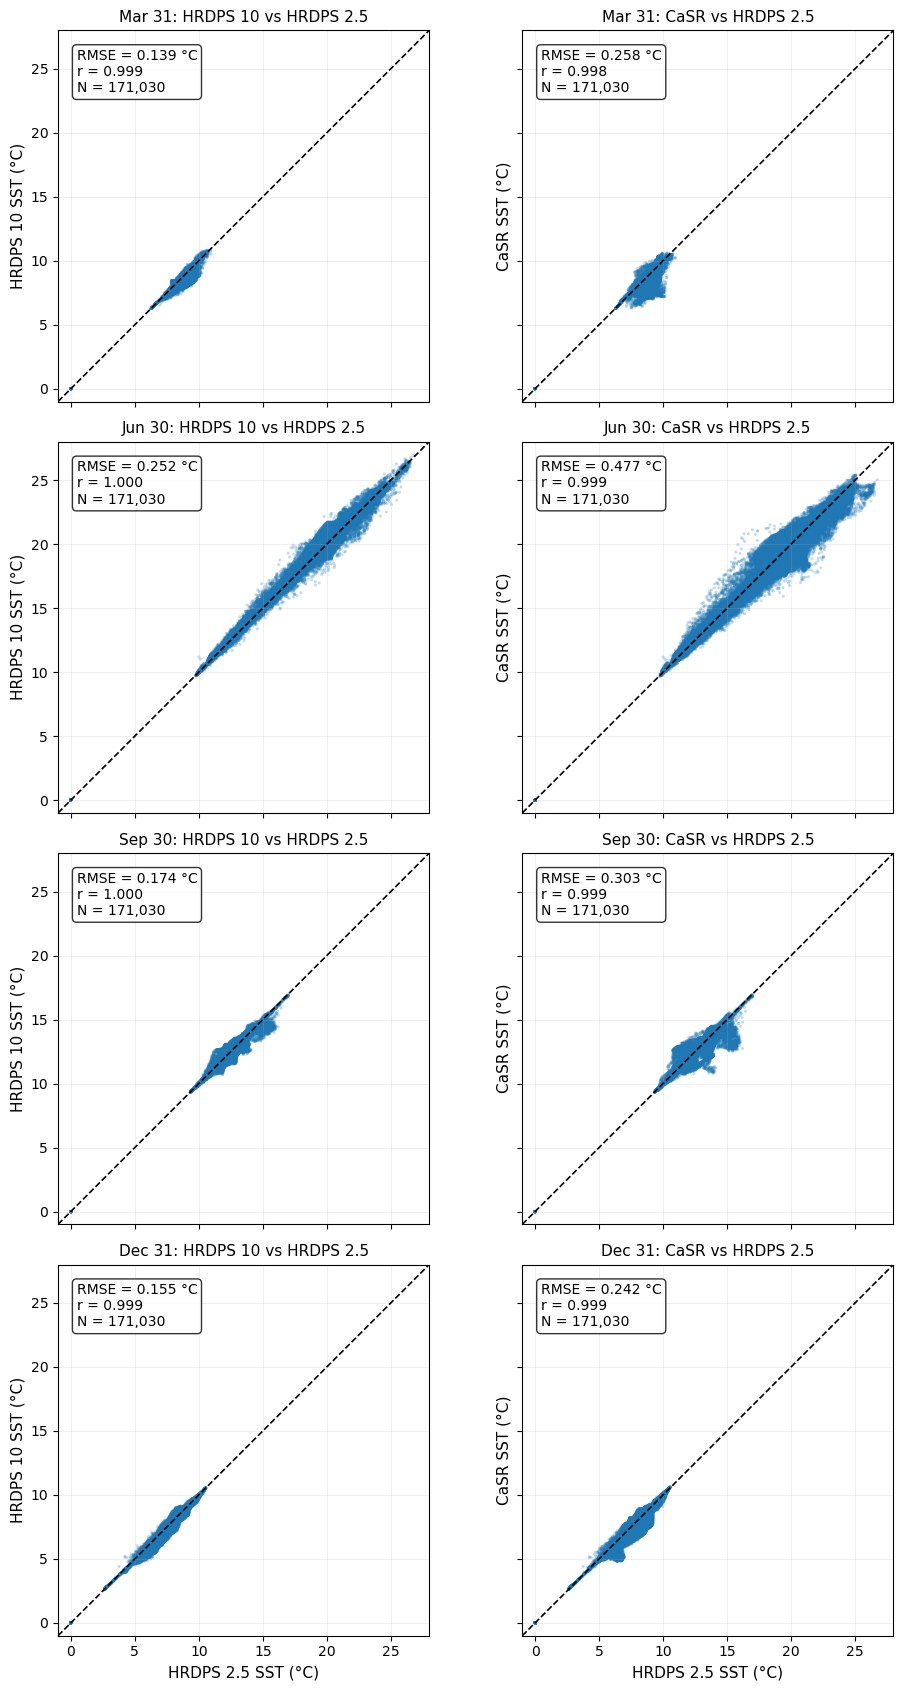

In [3]:
# ============================================================
# Scatter plots of surface SST on the LAST DAY of each month
#
# 4 rows x 2 columns:
#
# Left:
#     HRDPS 10 vs HRDPS 2.5
#
# Right:
#     CaSR vs HRDPS 2.5
#
# Rows:
#     March 31
#     June 30
#     September 30
#     December 31
#
# Statistics:
#     RMSE
#     Pearson correlation coefficient r
#
# x-axis = HRDPS 2.5 SST
# y-axis = HRDPS 10 or CaSR SST
# ============================================================

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# HRDPS 10 monthly grid_T files
# ============================================================
path_HRDPS10_mar_t = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_HRDPS10_jun_t = (
    '/ocean/jqiu/results/Flux/flux_00jun23_hrdps10/'
    'SalishSea_1d_20230601_20230630_grid_T.nc'
)

path_HRDPS10_sep_t = (
    '/ocean/jqiu/results/Flux/flux_00sep23_hrdps10/'
    'SalishSea_1d_20230901_20230930_grid_T.nc'
)

path_HRDPS10_dec_t = (
    '/ocean/jqiu/results/Flux/flux_00dec23_hrdps10/'
    'SalishSea_1d_20231201_20231231_grid_T.nc'
)


# ============================================================
# CaSR monthly grid_T files
# ============================================================
path_CaSR_mar_t = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_CaSR_jun_t = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_T.nc'
)

path_CaSR_sep_t = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_T.nc'
)

path_CaSR_dec_t = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_T.nc'
)


# ============================================================
# HRDPS 2.5 daily-file base path
# ============================================================
path_HRDPS25_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Month configuration
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'last_day': 31,
        'hrdps10_path': path_HRDPS10_mar_t,
        'casr_path': path_CaSR_mar_t,
    },

    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'last_day': 30,
        'hrdps10_path': path_HRDPS10_jun_t,
        'casr_path': path_CaSR_jun_t,
    },

    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'last_day': 30,
        'hrdps10_path': path_HRDPS10_sep_t,
        'casr_path': path_CaSR_sep_t,
    },

    {
        'name': 'December',
        'short': 'Dec',
        'month_num': 12,
        'month_str': 'dec',
        'last_day': 31,
        'hrdps10_path': path_HRDPS10_dec_t,
        'casr_path': path_CaSR_dec_t,
    },
]


# ============================================================
# Surface layer
# ============================================================
depth_idx = 0


# ============================================================
# Build HRDPS 2.5 daily path
# ============================================================
def get_hrdps25_path(month_num, month_str, day_num):

    date_str = f'2023{month_num:02d}{day_num:02d}'

    folder = f'{day_num:02d}{month_str}23'

    filename = (
        f'SalishSea_1d_'
        f'{date_str}_{date_str}_grid_T.nc'
    )

    return os.path.join(
        path_HRDPS25_base,
        folder,
        filename
    )


# ============================================================
# Function:
# Keep only paired finite values
# ============================================================
def get_valid_pairs(reference, experiment):

    reference = np.asarray(reference).ravel()
    experiment = np.asarray(experiment).ravel()

    mask = (
        np.isfinite(reference)
        & np.isfinite(experiment)
    )

    x = reference[mask]
    y = experiment[mask]

    return x, y


# ============================================================
# Function:
# Calculate RMSE and correlation
# ============================================================
def calculate_stats(x, y):

    rmse = np.sqrt(
        np.mean((y - x) ** 2)
    )

    # Pearson correlation coefficient
    if len(x) > 1:
        r = np.corrcoef(x, y)[0, 1]
    else:
        r = np.nan

    return rmse, r


# ============================================================
# Read all data first
# ============================================================
all_data = []


for month in months:

    day_num = month['last_day']

    print(
        f"\nReading "
        f"{month['name']} {day_num}, 2023"
    )

    # --------------------------------------------------------
    # Monthly-file time index
    #
    # March 31 -> index 30
    # June 30 -> index 29
    # etc.
    # --------------------------------------------------------
    tidx = day_num - 1


    # ========================================================
    # HRDPS 2.5 daily file
    # ========================================================
    hrdps25_path = get_hrdps25_path(
        month_num=month['month_num'],
        month_str=month['month_str'],
        day_num=day_num
    )

    if not os.path.exists(hrdps25_path):
        raise FileNotFoundError(
            f'HRDPS 2.5 file not found:\n'
            f'{hrdps25_path}'
        )


    # ========================================================
    # Open datasets
    # ========================================================
    ds_h10 = xr.open_dataset(
        month['hrdps10_path']
    )

    ds_casr = xr.open_dataset(
        month['casr_path']
    )

    ds_h25 = xr.open_dataset(
        hrdps25_path
    )


    # ========================================================
    # Surface SST
    # ========================================================

    # HRDPS 10:
    # monthly file, so use tidx
    sst_h10 = ds_h10['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # CaSR:
    # monthly file, so use tidx
    sst_casr = ds_casr['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # HRDPS 2.5:
    # daily file, so time index = 0
    sst_h25 = ds_h25['votemper'].isel(
        time_counter=0,
        deptht=depth_idx
    ).values


    # ========================================================
    # Paired valid data
    # ========================================================

    # HRDPS 10 vs HRDPS 2.5
    x_h10, y_h10 = get_valid_pairs(
        sst_h25,
        sst_h10
    )


    # CaSR vs HRDPS 2.5
    x_casr, y_casr = get_valid_pairs(
        sst_h25,
        sst_casr
    )


    # ========================================================
    # Statistics
    # ========================================================
    rmse_h10, r_h10 = calculate_stats(
        x_h10,
        y_h10
    )

    rmse_casr, r_casr = calculate_stats(
        x_casr,
        y_casr
    )


    print(
        f'HRDPS 10 vs HRDPS 2.5: '
        f'N={len(x_h10)}, '
        f'RMSE={rmse_h10:.3f} °C, '
        f'r={r_h10:.3f}'
    )

    print(
        f'CaSR vs HRDPS 2.5: '
        f'N={len(x_casr)}, '
        f'RMSE={rmse_casr:.3f} °C, '
        f'r={r_casr:.3f}'
    )


    # ========================================================
    # Save
    # ========================================================
    all_data.append({

        'name': month['name'],
        'short': month['short'],
        'day': day_num,

        'x_h10': x_h10,
        'y_h10': y_h10,
        'rmse_h10': rmse_h10,
        'r_h10': r_h10,

        'x_casr': x_casr,
        'y_casr': y_casr,
        'rmse_casr': rmse_casr,
        'r_casr': r_casr,
    })


    # ========================================================
    # Close files
    # ========================================================
    ds_h10.close()
    ds_casr.close()
    ds_h25.close()


# ============================================================
# Get ONE common temperature range
#
# This makes all 8 panels directly comparable
# ============================================================
all_temperature = []

for data in all_data:

    all_temperature.extend([
        data['x_h10'],
        data['y_h10'],
        data['x_casr'],
        data['y_casr'],
    ])


all_temperature = np.concatenate(
    all_temperature
)


temp_min = np.nanmin(all_temperature)
temp_max = np.nanmax(all_temperature)


# Small padding around plot limits
padding = 0.5

plot_min = np.floor(
    temp_min - padding
)

plot_max = np.ceil(
    temp_max + padding
)


print(
    f'\nCommon plot range: '
    f'{plot_min:.1f} to {plot_max:.1f} °C'
)


# ============================================================
# Plot
#
# 4 rows × 2 columns
# ============================================================
fig, axes = plt.subplots(
    4,
    2,
    figsize=(10, 17),
    sharex=True,
    sharey=True
)


for row, data in enumerate(all_data):

    # ========================================================
    # Left column:
    # HRDPS 10 vs HRDPS 2.5
    # ========================================================
    ax = axes[row, 0]

    ax.scatter(
        data['x_h10'],
        data['y_h10'],
        s=5,
        alpha=0.25,
        edgecolors='none'
    )


    # 1:1 line
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        'k--',
        linewidth=1.2
    )


    ax.set_xlim(
        plot_min,
        plot_max
    )

    ax.set_ylim(
        plot_min,
        plot_max
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )


    ax.set_title(
        f"{data['short']} {data['day']:02d}: "
        f"HRDPS 10 vs HRDPS 2.5",
        fontsize=11
    )


    # Statistics box
    ax.text(
        0.05,
        0.95,
        (
            f"RMSE = {data['rmse_h10']:.3f} °C\n"
            f"r = {data['r_h10']:.3f}\n"
            f"N = {len(data['x_h10']):,}"
        ),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )


    ax.grid(
        alpha=0.2
    )


    # ========================================================
    # Right column:
    # CaSR vs HRDPS 2.5
    # ========================================================
    ax = axes[row, 1]

    ax.scatter(
        data['x_casr'],
        data['y_casr'],
        s=5,
        alpha=0.25,
        edgecolors='none'
    )


    # 1:1 line
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        'k--',
        linewidth=1.2
    )


    ax.set_xlim(
        plot_min,
        plot_max
    )

    ax.set_ylim(
        plot_min,
        plot_max
    )

    ax.set_aspect(
        'equal',
        adjustable='box'
    )


    ax.set_title(
        f"{data['short']} {data['day']:02d}: "
        f"CaSR vs HRDPS 2.5",
        fontsize=11
    )


    # Statistics box
    ax.text(
        0.05,
        0.95,
        (
            f"RMSE = {data['rmse_casr']:.3f} °C\n"
            f"r = {data['r_casr']:.3f}\n"
            f"N = {len(data['x_casr']):,}"
        ),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )


    ax.grid(
        alpha=0.2
    )


# ============================================================
# Axis labels
# ============================================================

for row in range(4):

    axes[row, 0].set_ylabel(
        'HRDPS 10 SST (°C)',
        fontsize=11
    )

    axes[row, 1].set_ylabel(
        'CaSR SST (°C)',
        fontsize=11
    )


axes[3, 0].set_xlabel(
    'HRDPS 2.5 SST (°C)',
    fontsize=11
)

axes[3, 1].set_xlabel(
    'HRDPS 2.5 SST (°C)',
    fontsize=11
)




# ============================================================
# Layout
# ============================================================
plt.tight_layout()

plt.show()

Subsampled-HRDPS performs better than CaSR, although it has the same problem in the fjords.

## Surface Current

### Velocity Scatter Plot


March 31, 2023

HRDPS 2.5 hourly U:
/results2/SalishSea/nowcast-green.202111/31mar23/SalishSea_1h_20230331_20230331_grid_U.nc

HRDPS 2.5 hourly V:
/results2/SalishSea/nowcast-green.202111/31mar23/SalishSea_1h_20230331_20230331_grid_V.nc

HRDPS 2.5 hourly records: U=24, V=24

Surface array shapes:
HRDPS 10 : (898, 398)
CaSR     : (898, 398)
HRDPS 2.5: (898, 398)

HRDPS 10 vs HRDPS 2.5
N    = 171,030
RMSE = 0.0185 m/s
Bias = -0.0009 m/s
r    = 0.9752

CaSR vs HRDPS 2.5
N    = 171,030
RMSE = 0.0268 m/s
Bias = -0.0006 m/s
r    = 0.9483

June 30, 2023

HRDPS 2.5 hourly U:
/results2/SalishSea/nowcast-green.202111/30jun23/SalishSea_1h_20230630_20230630_grid_U.nc

HRDPS 2.5 hourly V:
/results2/SalishSea/nowcast-green.202111/30jun23/SalishSea_1h_20230630_20230630_grid_V.nc

HRDPS 2.5 hourly records: U=24, V=24

Surface array shapes:
HRDPS 10 : (898, 398)
CaSR     : (898, 398)
HRDPS 2.5: (898, 398)

HRDPS 10 vs HRDPS 2.5
N    = 171,030
RMSE = 0.0224 m/s
Bias = -0.0007 m/s
r    = 0.9778

CaSR vs

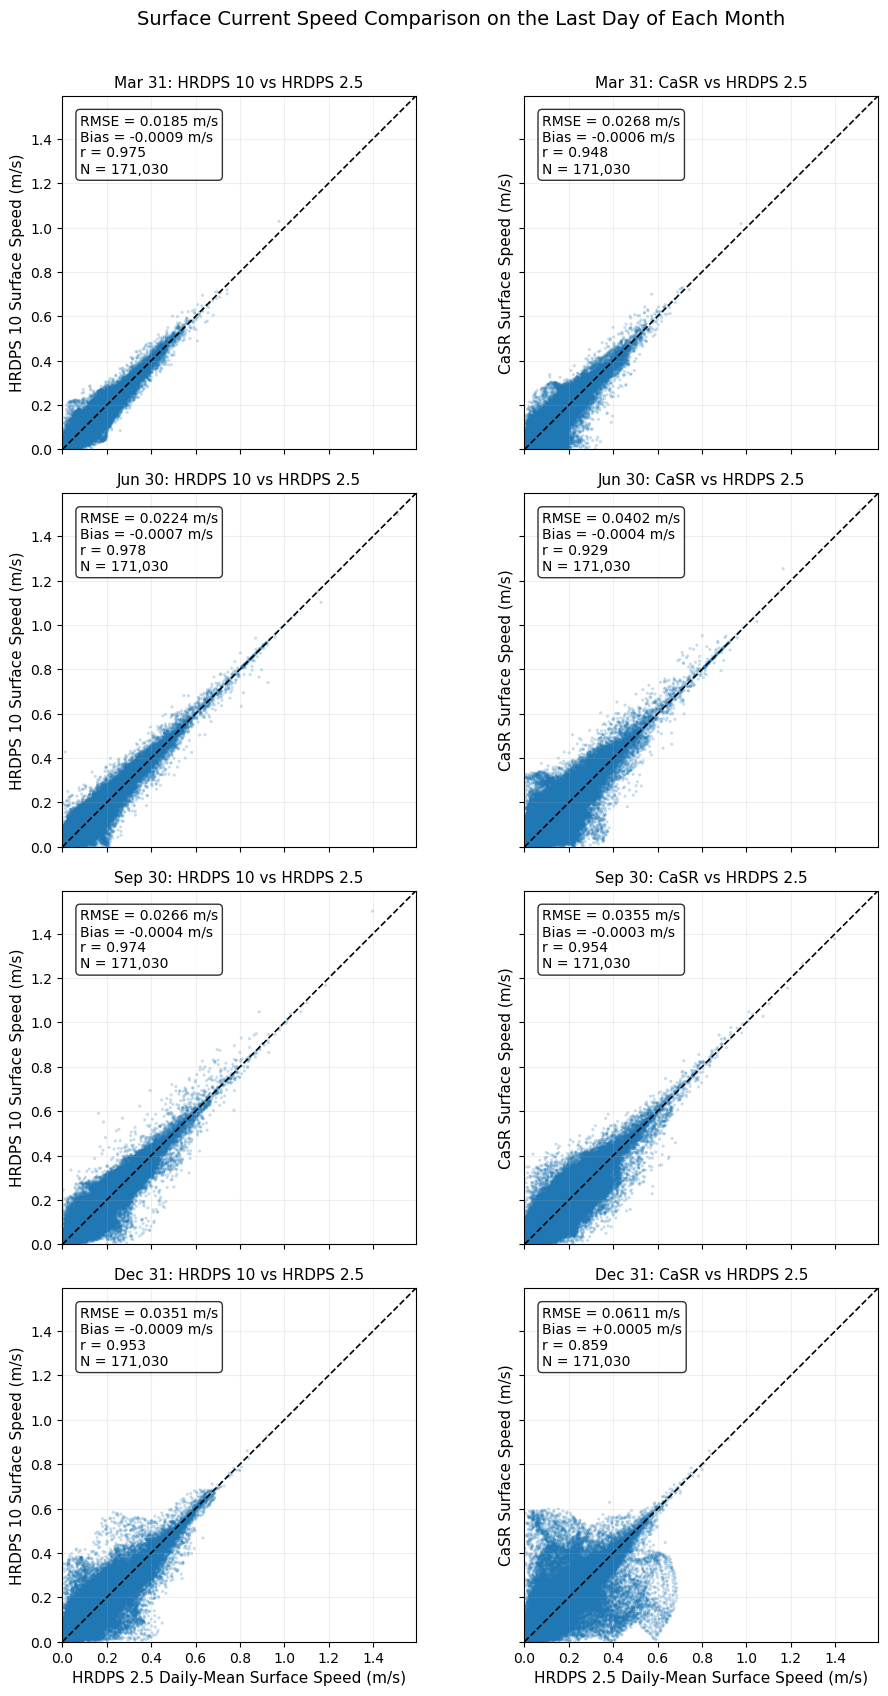

In [ ]:
# ============================================================
# Surface current speed comparison on LAST DAY of each month
#
# 4 rows x 2 columns
#
# Left:
#     HRDPS 10 (1d) vs HRDPS 2.5 (daily mean from 1h)
#
# Right:
#     CaSR (1d) vs HRDPS 2.5 (daily mean from 1h)
#
# HRDPS 2.5:
#     read 1h grid_U + grid_V
#     -> average U and V over time_counter
#     -> calculate speed from daily-mean U and V
#
# Speed:
#     sqrt(u^2 + v^2)
#
# NOTE:
# U/V are staggered.
# No interpolation is done here.
# Arrays are combined directly by matrix position.
# ============================================================

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# HRDPS 10 monthly grid_U
# ============================================================
path_HRDPS10_mar_u = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_U.nc'
)

path_HRDPS10_jun_u = (
    '/ocean/jqiu/results/Flux/flux_00jun23_hrdps10/'
    'SalishSea_1d_20230601_20230630_grid_U.nc'
)

path_HRDPS10_sep_u = (
    '/ocean/jqiu/results/Flux/flux_00sep23_hrdps10/'
    'SalishSea_1d_20230901_20230930_grid_U.nc'
)

path_HRDPS10_dec_u = (
    '/ocean/jqiu/results/Flux/flux_00dec23_hrdps10/'
    'SalishSea_1d_20231201_20231231_grid_U.nc'
)


# ============================================================
# HRDPS 10 monthly grid_V
# ============================================================
path_HRDPS10_mar_v = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_V.nc'
)

path_HRDPS10_jun_v = (
    '/ocean/jqiu/results/Flux/flux_00jun23_hrdps10/'
    'SalishSea_1d_20230601_20230630_grid_V.nc'
)

path_HRDPS10_sep_v = (
    '/ocean/jqiu/results/Flux/flux_00sep23_hrdps10/'
    'SalishSea_1d_20230901_20230930_grid_V.nc'
)

path_HRDPS10_dec_v = (
    '/ocean/jqiu/results/Flux/flux_00dec23_hrdps10/'
    'SalishSea_1d_20231201_20231231_grid_V.nc'
)


# ============================================================
# CaSR monthly grid_U
# ============================================================
path_CaSR_mar_u = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_U.nc'
)

path_CaSR_jun_u = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_U.nc'
)

path_CaSR_sep_u = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_U.nc'
)

path_CaSR_dec_u = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_U.nc'
)


# ============================================================
# CaSR monthly grid_V
# ============================================================
path_CaSR_mar_v = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_V.nc'
)

path_CaSR_jun_v = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_V.nc'
)

path_CaSR_sep_v = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_V.nc'
)

path_CaSR_dec_v = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_V.nc'
)


# ============================================================
# HRDPS 2.5 base path
#
# Example folder:
# /results2/SalishSea/nowcast-green.202111/31mar23/
#
# Hourly files assumed:
#
# SalishSea_1h_20230331_20230331_grid_U.nc
# SalishSea_1h_20230331_20230331_grid_V.nc
# ============================================================
path_HRDPS25_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Month configuration
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'last_day': 31,

        'h10_u': path_HRDPS10_mar_u,
        'h10_v': path_HRDPS10_mar_v,

        'casr_u': path_CaSR_mar_u,
        'casr_v': path_CaSR_mar_v,
    },

    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'last_day': 30,

        'h10_u': path_HRDPS10_jun_u,
        'h10_v': path_HRDPS10_jun_v,

        'casr_u': path_CaSR_jun_u,
        'casr_v': path_CaSR_jun_v,
    },

    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'last_day': 30,

        'h10_u': path_HRDPS10_sep_u,
        'h10_v': path_HRDPS10_sep_v,

        'casr_u': path_CaSR_sep_u,
        'casr_v': path_CaSR_sep_v,
    },

    {
        'name': 'December',
        'short': 'Dec',
        'month_num': 12,
        'month_str': 'dec',
        'last_day': 31,

        'h10_u': path_HRDPS10_dec_u,
        'h10_v': path_HRDPS10_dec_v,

        'casr_u': path_CaSR_dec_u,
        'casr_v': path_CaSR_dec_v,
    },
]


# ============================================================
# Surface layer
# ============================================================
depth_idx = 0


# ============================================================
# Build HRDPS 2.5 HOURLY file path
# ============================================================
def get_hrdps25_hourly_path(
    month_num,
    month_str,
    day_num,
    grid
):

    date_str = (
        f'2023{month_num:02d}{day_num:02d}'
    )

    folder = (
        f'{day_num:02d}{month_str}23'
    )

    filename = (
        f'SalishSea_1h_'
        f'{date_str}_{date_str}_'
        f'grid_{grid}.nc'
    )

    return os.path.join(
        path_HRDPS25_base,
        folder,
        filename
    )


# ============================================================
# Speed from U and V
#
# No staggered-grid interpolation.
# Direct matrix-position calculation.
# ============================================================
def calculate_speed(u, v):

    if u.shape != v.shape:

        raise ValueError(
            f'U and V shapes are different:\n'
            f'U shape = {u.shape}\n'
            f'V shape = {v.shape}'
        )

    return np.sqrt(
        u**2 + v**2
    )


# ============================================================
# Valid paired values
# ============================================================
def get_valid_pairs(reference, experiment):

    reference = np.asarray(
        reference
    ).ravel()

    experiment = np.asarray(
        experiment
    ).ravel()

    mask = (
        np.isfinite(reference)
        & np.isfinite(experiment)
    )

    return (
        reference[mask],
        experiment[mask]
    )


# ============================================================
# Statistics
# ============================================================
def calculate_stats(x, y):

    rmse = np.sqrt(
        np.mean(
            (y - x)**2
        )
    )

    if len(x) > 1:

        r = np.corrcoef(
            x,
            y
        )[0, 1]

    else:

        r = np.nan

    # Optional bias:
    # positive = experiment faster than HRDPS 2.5
    bias = np.mean(
        y - x
    )

    return rmse, r, bias


# ============================================================
# Read all months
# ============================================================
all_data = []


for month in months:

    day_num = month['last_day']

    # Monthly 1d file index
    tidx = day_num - 1


    print(
        '\n=============================================='
    )

    print(
        f"{month['name']} {day_num}, 2023"
    )


    # ========================================================
    # HRDPS 2.5 hourly files
    # ========================================================
    h25_u_path = get_hrdps25_hourly_path(
        month_num=month['month_num'],
        month_str=month['month_str'],
        day_num=day_num,
        grid='U'
    )

    h25_v_path = get_hrdps25_hourly_path(
        month_num=month['month_num'],
        month_str=month['month_str'],
        day_num=day_num,
        grid='V'
    )


    print(
        '\nHRDPS 2.5 hourly U:'
    )

    print(
        h25_u_path
    )

    print(
        '\nHRDPS 2.5 hourly V:'
    )

    print(
        h25_v_path
    )


    # ========================================================
    # Safety check
    # ========================================================
    paths_to_check = [

        month['h10_u'],
        month['h10_v'],

        month['casr_u'],
        month['casr_v'],

        h25_u_path,
        h25_v_path,
    ]


    for path in paths_to_check:

        if not os.path.exists(path):

            raise FileNotFoundError(
                f'File not found:\n{path}'
            )


    # ========================================================
    # Open datasets
    # ========================================================
    ds_h10_u = xr.open_dataset(
        month['h10_u']
    )

    ds_h10_v = xr.open_dataset(
        month['h10_v']
    )


    ds_casr_u = xr.open_dataset(
        month['casr_u']
    )

    ds_casr_v = xr.open_dataset(
        month['casr_v']
    )


    ds_h25_u = xr.open_dataset(
        h25_u_path
    )

    ds_h25_v = xr.open_dataset(
        h25_v_path
    )


    # ========================================================
    # Check HRDPS 2.5 number of hourly records
    # ========================================================
    ntime_u = ds_h25_u.sizes[
        'time_counter'
    ]

    ntime_v = ds_h25_v.sizes[
        'time_counter'
    ]


    print(
        f'\nHRDPS 2.5 hourly records: '
        f'U={ntime_u}, V={ntime_v}'
    )


    if ntime_u != 24 or ntime_v != 24:

        print(
            'WARNING: expected 24 hourly records, '
            'but file does not contain exactly 24.'
        )


    # ========================================================
    # HRDPS 10
    #
    # Already DAILY averaged
    # ========================================================
    h10_u = ds_h10_u[
        'vozocrtx'
    ].isel(
        time_counter=tidx,
        depthu=depth_idx
    ).values


    h10_v = ds_h10_v[
        'vomecrty'
    ].isel(
        time_counter=tidx,
        depthv=depth_idx
    ).values


    h10_speed = calculate_speed(
        h10_u,
        h10_v
    )


    # ========================================================
    # CaSR
    #
    # Already DAILY averaged
    # ========================================================
    casr_u = ds_casr_u[
        'vozocrtx'
    ].isel(
        time_counter=tidx,
        depthu=depth_idx
    ).values


    casr_v = ds_casr_v[
        'vomecrty'
    ].isel(
        time_counter=tidx,
        depthv=depth_idx
    ).values


    casr_speed = calculate_speed(
        casr_u,
        casr_v
    )


    # ========================================================
    # HRDPS 2.5
    #
    # HOURLY -> DAILY MEAN
    #
    # IMPORTANT:
    #
    # First:
    #     mean(U over 24h)
    #     mean(V over 24h)
    #
    # Then:
    #     speed = sqrt(U_daily^2 + V_daily^2)
    #
    # ========================================================

    h25_u_daily = (
        ds_h25_u['vozocrtx']
        .isel(
            depthu=depth_idx
        )
        .mean(
            dim='time_counter',
            skipna=True
        )
        .values
    )


    h25_v_daily = (
        ds_h25_v['vomecrty']
        .isel(
            depthv=depth_idx
        )
        .mean(
            dim='time_counter',
            skipna=True
        )
        .values
    )


    h25_speed = calculate_speed(
        h25_u_daily,
        h25_v_daily
    )


    # ========================================================
    # Check shapes
    # ========================================================
    print(
        '\nSurface array shapes:'
    )

    print(
        f'HRDPS 10 : {h10_speed.shape}'
    )

    print(
        f'CaSR     : {casr_speed.shape}'
    )

    print(
        f'HRDPS 2.5: {h25_speed.shape}'
    )


    if h10_speed.shape != h25_speed.shape:

        raise ValueError(
            'HRDPS 10 and HRDPS 2.5 '
            'have different horizontal shapes.'
        )


    if casr_speed.shape != h25_speed.shape:

        raise ValueError(
            'CaSR and HRDPS 2.5 '
            'have different horizontal shapes.'
        )


    # ========================================================
    # Paired values
    # ========================================================

    # HRDPS 10 vs HRDPS 2.5
    x_h10, y_h10 = get_valid_pairs(
        h25_speed,
        h10_speed
    )


    # CaSR vs HRDPS 2.5
    x_casr, y_casr = get_valid_pairs(
        h25_speed,
        casr_speed
    )


    # ========================================================
    # Statistics
    # ========================================================
    rmse_h10, r_h10, bias_h10 = calculate_stats(
        x_h10,
        y_h10
    )


    rmse_casr, r_casr, bias_casr = calculate_stats(
        x_casr,
        y_casr
    )


    # ========================================================
    # Print results
    # ========================================================
    print(
        '\nHRDPS 10 vs HRDPS 2.5'
    )

    print(
        f'N    = {len(x_h10):,}'
    )

    print(
        f'RMSE = {rmse_h10:.4f} m/s'
    )

    print(
        f'Bias = {bias_h10:+.4f} m/s'
    )

    print(
        f'r    = {r_h10:.4f}'
    )


    print(
        '\nCaSR vs HRDPS 2.5'
    )

    print(
        f'N    = {len(x_casr):,}'
    )

    print(
        f'RMSE = {rmse_casr:.4f} m/s'
    )

    print(
        f'Bias = {bias_casr:+.4f} m/s'
    )

    print(
        f'r    = {r_casr:.4f}'
    )


    # ========================================================
    # Save
    # ========================================================
    all_data.append({

        'name': month['name'],
        'short': month['short'],
        'day': day_num,

        # HRDPS 10
        'x_h10': x_h10,
        'y_h10': y_h10,

        'rmse_h10': rmse_h10,
        'r_h10': r_h10,
        'bias_h10': bias_h10,

        # CaSR
        'x_casr': x_casr,
        'y_casr': y_casr,

        'rmse_casr': rmse_casr,
        'r_casr': r_casr,
        'bias_casr': bias_casr,
    })


    # ========================================================
    # Close files
    # ========================================================
    ds_h10_u.close()
    ds_h10_v.close()

    ds_casr_u.close()
    ds_casr_v.close()

    ds_h25_u.close()
    ds_h25_v.close()


# ============================================================
# ONE common axis range
# ============================================================
all_speed = []


for data in all_data:

    all_speed.extend([

        data['x_h10'],
        data['y_h10'],

        data['x_casr'],
        data['y_casr'],
    ])


all_speed = np.concatenate(
    all_speed
)


plot_min = 0.0


plot_max = np.nanmax(
    all_speed
)


# 5% padding
plot_max *= 1.05


print(
    '\n=============================================='
)

print(
    f'Common plotting range: '
    f'{plot_min:.3f} - {plot_max:.3f} m/s'
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    4,
    2,
    figsize=(10, 17),
    sharex=True,
    sharey=True
)


for row, data in enumerate(all_data):


    # ========================================================
    # LEFT:
    # HRDPS 10 vs HRDPS 2.5
    # ========================================================
    ax = axes[row, 0]


    ax.scatter(
        data['x_h10'],
        data['y_h10'],
        s=5,
        alpha=0.25,
        edgecolors='none'
    )


    # 1:1 line
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        'k--',
        linewidth=1.2
    )


    ax.set_xlim(
        plot_min,
        plot_max
    )

    ax.set_ylim(
        plot_min,
        plot_max
    )


    ax.set_aspect(
        'equal',
        adjustable='box'
    )


    ax.set_title(
        f"{data['short']} {data['day']:02d}: "
        f"HRDPS 10 vs HRDPS 2.5",
        fontsize=11
    )


    ax.text(
        0.05,
        0.95,

        (
            f"RMSE = {data['rmse_h10']:.4f} m/s\n"
            f"Bias = {data['bias_h10']:+.4f} m/s\n"
            f"r = {data['r_h10']:.3f}\n"
            f"N = {len(data['x_h10']):,}"
        ),

        transform=ax.transAxes,

        ha='left',
        va='top',

        fontsize=10,

        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )


    ax.grid(
        alpha=0.2
    )


    # ========================================================
    # RIGHT:
    # CaSR vs HRDPS 2.5
    # ========================================================
    ax = axes[row, 1]


    ax.scatter(
        data['x_casr'],
        data['y_casr'],
        s=5,
        alpha=0.25,
        edgecolors='none'
    )


    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        'k--',
        linewidth=1.2
    )


    ax.set_xlim(
        plot_min,
        plot_max
    )

    ax.set_ylim(
        plot_min,
        plot_max
    )


    ax.set_aspect(
        'equal',
        adjustable='box'
    )


    ax.set_title(
        f"{data['short']} {data['day']:02d}: "
        f"CaSR vs HRDPS 2.5",
        fontsize=11
    )


    ax.text(
        0.05,
        0.95,

        (
            f"RMSE = {data['rmse_casr']:.4f} m/s\n"
            f"Bias = {data['bias_casr']:+.4f} m/s\n"
            f"r = {data['r_casr']:.3f}\n"
            f"N = {len(data['x_casr']):,}"
        ),

        transform=ax.transAxes,

        ha='left',
        va='top',

        fontsize=10,

        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )


    ax.grid(
        alpha=0.2
    )


# ============================================================
# Axis labels
# ============================================================
for row in range(4):

    axes[row, 0].set_ylabel(
        'HRDPS 10 Surface Speed (m/s)',
        fontsize=11
    )

    axes[row, 1].set_ylabel(
        'CaSR Surface Speed (m/s)',
        fontsize=11
    )


axes[3, 0].set_xlabel(
    'HRDPS 2.5 Daily-Mean Surface Speed (m/s)',
    fontsize=11
)


axes[3, 1].set_xlabel(
    'HRDPS 2.5 Daily-Mean Surface Speed (m/s)',
    fontsize=11
)


# ============================================================
# Overall title
# ============================================================
fig.suptitle()


plt.tight_layout()


plt.show()

### Surface Velocity Map


March 31, 2023
HRDPS 2.5 records: U=24, V=24
HRDPS10 mean bias = -0.0009 m/s
CaSR mean bias     = -0.0006 m/s

June 30, 2023
HRDPS 2.5 records: U=24, V=24
HRDPS10 mean bias = -0.0007 m/s
CaSR mean bias     = -0.0004 m/s

September 30, 2023
HRDPS 2.5 records: U=24, V=24
HRDPS10 mean bias = -0.0004 m/s
CaSR mean bias     = -0.0003 m/s

December 31, 2023
HRDPS 2.5 records: U=24, V=24
HRDPS10 mean bias = -0.0009 m/s
CaSR mean bias     = +0.0005 m/s

Unified color range = -0.5821 to 0.5821 m/s


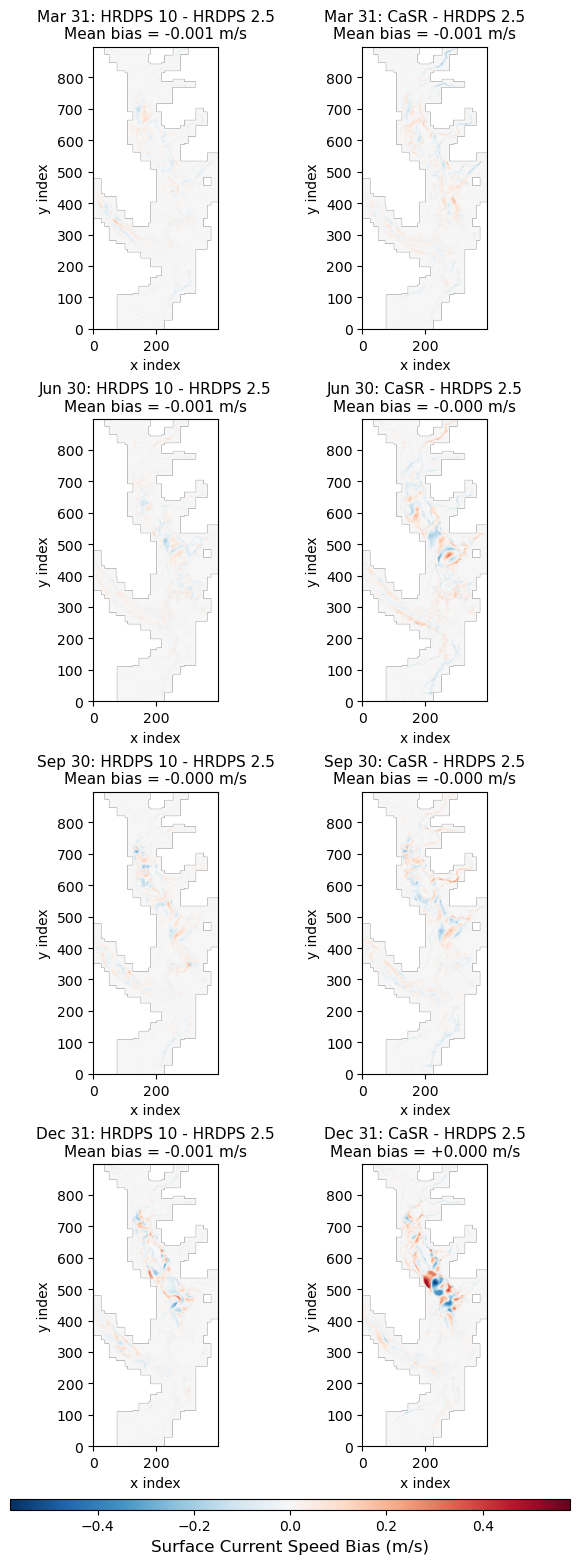

In [8]:
# ============================================================
# Surface current speed BIAS maps
# on the LAST DAY of each month
#
# 4 rows x 2 columns
#
# Left:
#     HRDPS 10 - HRDPS 2.5
#
# Right:
#     CaSR - HRDPS 2.5
#
# Bias definition:
#
#     bias = experiment_speed - HRDPS2.5_speed
#
# positive = experiment faster
# negative = experiment slower
#
# HRDPS 2.5:
#     hourly U/V
#     -> daily mean U/V
#     -> speed
#
# U/V staggered grids:
#     no interpolation
#     directly combine by matrix position
# ============================================================

import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# HRDPS 10 monthly grid_U
# ============================================================
path_HRDPS10_mar_u = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_U.nc'
)

path_HRDPS10_jun_u = (
    '/ocean/jqiu/results/Flux/flux_00jun23_hrdps10/'
    'SalishSea_1d_20230601_20230630_grid_U.nc'
)

path_HRDPS10_sep_u = (
    '/ocean/jqiu/results/Flux/flux_00sep23_hrdps10/'
    'SalishSea_1d_20230901_20230930_grid_U.nc'
)

path_HRDPS10_dec_u = (
    '/ocean/jqiu/results/Flux/flux_00dec23_hrdps10/'
    'SalishSea_1d_20231201_20231231_grid_U.nc'
)


# ============================================================
# HRDPS 10 monthly grid_V
# ============================================================
path_HRDPS10_mar_v = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_V.nc'
)

path_HRDPS10_jun_v = (
    '/ocean/jqiu/results/Flux/flux_00jun23_hrdps10/'
    'SalishSea_1d_20230601_20230630_grid_V.nc'
)

path_HRDPS10_sep_v = (
    '/ocean/jqiu/results/Flux/flux_00sep23_hrdps10/'
    'SalishSea_1d_20230901_20230930_grid_V.nc'
)

path_HRDPS10_dec_v = (
    '/ocean/jqiu/results/Flux/flux_00dec23_hrdps10/'
    'SalishSea_1d_20231201_20231231_grid_V.nc'
)


# ============================================================
# CaSR monthly grid_U
# ============================================================
path_CaSR_mar_u = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_U.nc'
)

path_CaSR_jun_u = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_U.nc'
)

path_CaSR_sep_u = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_U.nc'
)

path_CaSR_dec_u = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_U.nc'
)


# ============================================================
# CaSR monthly grid_V
# ============================================================
path_CaSR_mar_v = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_grid_V.nc'
)

path_CaSR_jun_v = (
    '/ocean/jqiu/results/Flux/flux_00jun23_CaSR/'
    'SalishSea_1d_20230601_20230630_grid_V.nc'
)

path_CaSR_sep_v = (
    '/ocean/jqiu/results/Flux/flux_00sep23_CaSR/'
    'SalishSea_1d_20230901_20230930_grid_V.nc'
)

path_CaSR_dec_v = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_V.nc'
)


# ============================================================
# HRDPS 2.5 base path
#
# Hourly U/V files
# ============================================================
path_HRDPS25_base = (
    '/results2/SalishSea/nowcast-green.202111'
)


# ============================================================
# Month configuration
# ============================================================
months = [
    {
        'name': 'March',
        'short': 'Mar',
        'month_num': 3,
        'month_str': 'mar',
        'last_day': 31,

        'h10_u': path_HRDPS10_mar_u,
        'h10_v': path_HRDPS10_mar_v,

        'casr_u': path_CaSR_mar_u,
        'casr_v': path_CaSR_mar_v,
    },

    {
        'name': 'June',
        'short': 'Jun',
        'month_num': 6,
        'month_str': 'jun',
        'last_day': 30,

        'h10_u': path_HRDPS10_jun_u,
        'h10_v': path_HRDPS10_jun_v,

        'casr_u': path_CaSR_jun_u,
        'casr_v': path_CaSR_jun_v,
    },

    {
        'name': 'September',
        'short': 'Sep',
        'month_num': 9,
        'month_str': 'sep',
        'last_day': 30,

        'h10_u': path_HRDPS10_sep_u,
        'h10_v': path_HRDPS10_sep_v,

        'casr_u': path_CaSR_sep_u,
        'casr_v': path_CaSR_sep_v,
    },

    {
        'name': 'December',
        'short': 'Dec',
        'month_num': 12,
        'month_str': 'dec',
        'last_day': 31,

        'h10_u': path_HRDPS10_dec_u,
        'h10_v': path_HRDPS10_dec_v,

        'casr_u': path_CaSR_dec_u,
        'casr_v': path_CaSR_dec_v,
    },
]


# ============================================================
# Surface
# ============================================================
depth_idx = 0


# ============================================================
# Build HRDPS 2.5 hourly file path
# ============================================================
def get_hrdps25_hourly_path(
    month_num,
    month_str,
    day_num,
    grid
):

    date_str = (
        f'2023{month_num:02d}{day_num:02d}'
    )

    folder = (
        f'{day_num:02d}{month_str}23'
    )

    filename = (
        f'SalishSea_1h_'
        f'{date_str}_{date_str}_'
        f'grid_{grid}.nc'
    )

    return os.path.join(
        path_HRDPS25_base,
        folder,
        filename
    )


# ============================================================
# Calculate current speed
#
# No interpolation between staggered U/V grids.
# Direct matrix-position calculation.
# ============================================================
def calculate_speed(u, v):

    if u.shape != v.shape:

        raise ValueError(
            f'U/V shape mismatch:\n'
            f'U = {u.shape}\n'
            f'V = {v.shape}'
        )

    return np.sqrt(
        u**2 + v**2
    )


# ============================================================
# Storage
# ============================================================
all_data = []


# ============================================================
# Read data
# ============================================================
for month in months:

    day_num = month['last_day']

    # Monthly 1d index
    tidx = day_num - 1


    print(
        '\n=========================================='
    )

    print(
        f"{month['name']} {day_num}, 2023"
    )


    # ========================================================
    # HRDPS 2.5 hourly file paths
    # ========================================================
    h25_u_path = get_hrdps25_hourly_path(
        month_num=month['month_num'],
        month_str=month['month_str'],
        day_num=day_num,
        grid='U'
    )

    h25_v_path = get_hrdps25_hourly_path(
        month_num=month['month_num'],
        month_str=month['month_str'],
        day_num=day_num,
        grid='V'
    )


    # ========================================================
    # File check
    # ========================================================
    paths_to_check = [
        month['h10_u'],
        month['h10_v'],
        month['casr_u'],
        month['casr_v'],
        h25_u_path,
        h25_v_path,
    ]


    for path in paths_to_check:

        if not os.path.exists(path):

            raise FileNotFoundError(
                f'File not found:\n{path}'
            )


    # ========================================================
    # Open datasets
    # ========================================================
    ds_h10_u = xr.open_dataset(
        month['h10_u']
    )

    ds_h10_v = xr.open_dataset(
        month['h10_v']
    )


    ds_casr_u = xr.open_dataset(
        month['casr_u']
    )

    ds_casr_v = xr.open_dataset(
        month['casr_v']
    )


    ds_h25_u = xr.open_dataset(
        h25_u_path
    )

    ds_h25_v = xr.open_dataset(
        h25_v_path
    )


    # ========================================================
    # HRDPS 10:
    # daily mean U/V already available
    # ========================================================
    h10_u = ds_h10_u[
        'vozocrtx'
    ].isel(
        time_counter=tidx,
        depthu=depth_idx
    ).values


    h10_v = ds_h10_v[
        'vomecrty'
    ].isel(
        time_counter=tidx,
        depthv=depth_idx
    ).values


    h10_speed = calculate_speed(
        h10_u,
        h10_v
    )


    # ========================================================
    # CaSR:
    # daily mean U/V already available
    # ========================================================
    casr_u = ds_casr_u[
        'vozocrtx'
    ].isel(
        time_counter=tidx,
        depthu=depth_idx
    ).values


    casr_v = ds_casr_v[
        'vomecrty'
    ].isel(
        time_counter=tidx,
        depthv=depth_idx
    ).values


    casr_speed = calculate_speed(
        casr_u,
        casr_v
    )


    # ========================================================
    # HRDPS 2.5:
    #
    # hourly U/V
    # -> daily mean U/V
    # -> speed
    # ========================================================
    ntime_u = ds_h25_u.sizes[
        'time_counter'
    ]

    ntime_v = ds_h25_v.sizes[
        'time_counter'
    ]


    print(
        f'HRDPS 2.5 records: '
        f'U={ntime_u}, V={ntime_v}'
    )


    if ntime_u != 24 or ntime_v != 24:

        print(
            'WARNING: not exactly 24 hourly records!'
        )


    h25_u_daily = (
        ds_h25_u['vozocrtx']
        .isel(
            depthu=depth_idx
        )
        .mean(
            dim='time_counter',
            skipna=True
        )
        .values
    )


    h25_v_daily = (
        ds_h25_v['vomecrty']
        .isel(
            depthv=depth_idx
        )
        .mean(
            dim='time_counter',
            skipna=True
        )
        .values
    )


    h25_speed = calculate_speed(
        h25_u_daily,
        h25_v_daily
    )


    # ========================================================
    # Make sure horizontal shapes agree
    # ========================================================
    if h10_speed.shape != h25_speed.shape:

        raise ValueError(
            f'HRDPS10 / HRDPS2.5 shape mismatch:\n'
            f'{h10_speed.shape} vs {h25_speed.shape}'
        )


    if casr_speed.shape != h25_speed.shape:

        raise ValueError(
            f'CaSR / HRDPS2.5 shape mismatch:\n'
            f'{casr_speed.shape} vs {h25_speed.shape}'
        )


    # ========================================================
    # Spatial BIAS
    #
    # positive = experiment faster
    # negative = experiment slower
    # ========================================================
    bias_h10 = (
        h10_speed
        - h25_speed
    )


    bias_casr = (
        casr_speed
        - h25_speed
    )


    # ========================================================
    # Mean spatial bias
    # useful for printing / title checking
    # ========================================================
    mean_bias_h10 = np.nanmean(
        bias_h10
    )

    mean_bias_casr = np.nanmean(
        bias_casr
    )


    print(
        f'HRDPS10 mean bias = '
        f'{mean_bias_h10:+.4f} m/s'
    )

    print(
        f'CaSR mean bias     = '
        f'{mean_bias_casr:+.4f} m/s'
    )


    # ========================================================
    # Save
    # ========================================================
    all_data.append({
        'name': month['name'],
        'short': month['short'],
        'day': day_num,

        'bias_h10': bias_h10,
        'bias_casr': bias_casr,

        'mean_bias_h10': mean_bias_h10,
        'mean_bias_casr': mean_bias_casr,
    })


    # ========================================================
    # Close datasets
    # ========================================================
    ds_h10_u.close()
    ds_h10_v.close()

    ds_casr_u.close()
    ds_casr_v.close()

    ds_h25_u.close()
    ds_h25_v.close()


# ============================================================
# Unified color range
# across ALL 8 panels
#
# symmetric around zero
# ============================================================
all_bias_values = []


for data in all_data:

    # HRDPS 10
    valid_h10 = data['bias_h10'][
        np.isfinite(
            data['bias_h10']
        )
    ]

    if valid_h10.size > 0:

        all_bias_values.append(
            valid_h10
        )


    # CaSR
    valid_casr = data['bias_casr'][
        np.isfinite(
            data['bias_casr']
        )
    ]

    if valid_casr.size > 0:

        all_bias_values.append(
            valid_casr
        )


all_bias_values = np.concatenate(
    all_bias_values
)


# ============================================================
# Absolute maximum
#
# All panels use exactly the same range:
# [-bias_max, +bias_max]
# ============================================================
bias_max = np.nanmax(
    np.abs(
        all_bias_values
    )
)


print(
    '\n=========================================='
)

print(
    f'Unified color range = '
    f'{-bias_max:.4f} to '
    f'{bias_max:.4f} m/s'
)


# ============================================================
# Diverging normalization
# centered exactly at zero
# ============================================================
bias_norm = TwoSlopeNorm(
    vmin=-bias_max,
    vcenter=0,
    vmax=bias_max
)


# ============================================================
# Plot: 4 rows x 2 columns
# ============================================================
fig, axes = plt.subplots(
    4,
    2,
    figsize=(6, 16)
)


im = None


for row, data in enumerate(all_data):


    # ========================================================
    # LEFT:
    # HRDPS 10 - HRDPS 2.5
    # ========================================================
    ax = axes[row, 0]


    im = ax.imshow(
        data['bias_h10'],
        origin='lower',
        cmap='RdBu_r',
        norm=bias_norm,
        aspect='equal'
    )


    ax.set_title(
        (
            f"{data['short']} {data['day']:02d}: "
            f"HRDPS 10 - HRDPS 2.5\n"
            f"Mean bias = "
            f"{data['mean_bias_h10']:+.3f} m/s"
        ),
        fontsize=11
    )


    ax.set_xlabel(
        'x index'
    )

    ax.set_ylabel(
        'y index'
    )


    # ========================================================
    # RIGHT:
    # CaSR - HRDPS 2.5
    # ========================================================
    ax = axes[row, 1]


    im = ax.imshow(
        data['bias_casr'],
        origin='lower',
        cmap='RdBu_r',
        norm=bias_norm,
        aspect='equal'
    )


    ax.set_title(
        (
            f"{data['short']} {data['day']:02d}: "
            f"CaSR - HRDPS 2.5\n"
            f"Mean bias = "
            f"{data['mean_bias_casr']:+.3f} m/s"
        ),
        fontsize=11
    )


    ax.set_xlabel(
        'x index'
    )

    ax.set_ylabel(
        'y index'
    )



# ============================================================
# Layout
#
# Leave some space at bottom for colorbar
# ============================================================
plt.tight_layout()


# ============================================================
# ONE shared colorbar
# ============================================================
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.025,
    pad=0.035,
    aspect=50
)


cbar.set_label(
    (
        'Surface Current Speed Bias (m/s)'
    ),
    fontsize=12
)


cbar.ax.tick_params(
    labelsize=10
)


plt.show()

### What happened on Dec 31 in CaSR?



HRDPS 2.5 records: U=24, V=24
CaSR shapes: (898, 398) (898, 398)
HRDPS 2.5 shapes: (898, 398) (898, 398)
Max speed for color scale = 1.052 m/s


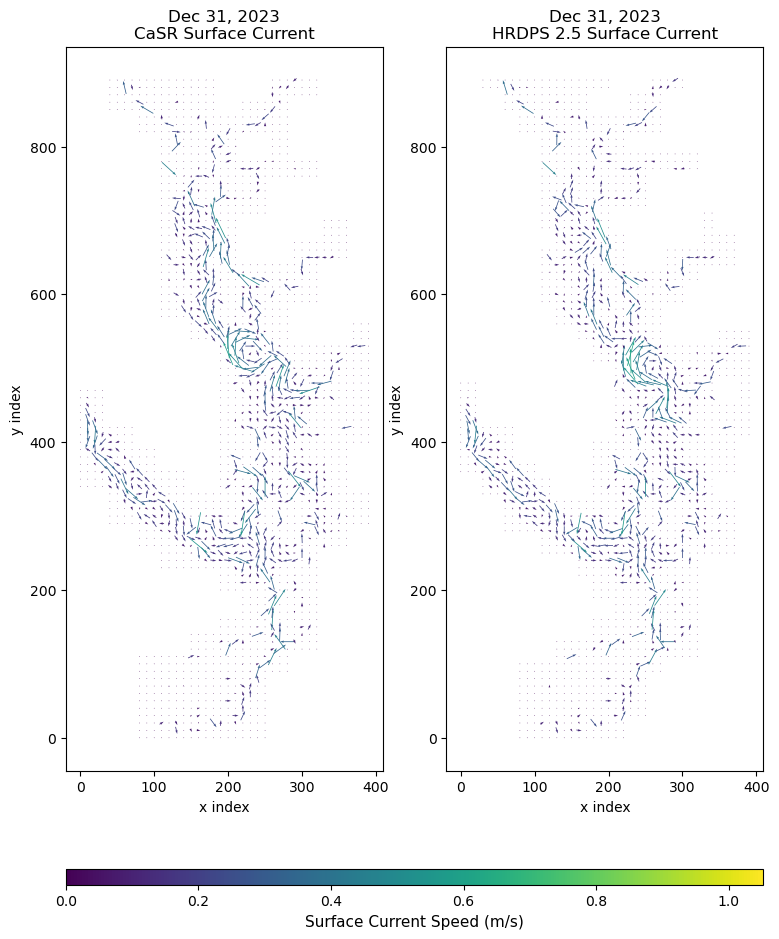

In [11]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Dec 31, 2023
# Surface vector plots:
#
# Left  : CaSR
# Right : HRDPS 2.5
#
# No grid alignment
# No map
# No interpolation between U/V staggered grids
# Direct matrix-position plotting
# ============================================================


# ============================================================
# CaSR monthly files
# ============================================================
path_CaSR_dec_u = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_U.nc'
)

path_CaSR_dec_v = (
    '/ocean/jqiu/results/Flux/flux_00dec23_CaSR/'
    'SalishSea_1d_20231201_20231231_grid_V.nc'
)


# ============================================================
# HRDPS 2.5 hourly files
# Dec 31, 2023
# ============================================================
path_HRDPS25_base = (
    '/results2/SalishSea/nowcast-green.202111'
)

path_HRDPS25_dec31_u = os.path.join(
    path_HRDPS25_base,
    '31dec23',
    'SalishSea_1h_20231231_20231231_grid_U.nc'
)

path_HRDPS25_dec31_v = os.path.join(
    path_HRDPS25_base,
    '31dec23',
    'SalishSea_1h_20231231_20231231_grid_V.nc'
)


# ============================================================
# Surface
# ============================================================
depth_idx = 0

# Dec 31 in monthly daily file
tidx = 30


# ============================================================
# Check files
# ============================================================
paths_to_check = [
    path_CaSR_dec_u,
    path_CaSR_dec_v,
    path_HRDPS25_dec31_u,
    path_HRDPS25_dec31_v,
]

for path in paths_to_check:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'File not found:\n{path}'
        )


# ============================================================
# Open datasets
# ============================================================
ds_casr_u = xr.open_dataset(
    path_CaSR_dec_u
)

ds_casr_v = xr.open_dataset(
    path_CaSR_dec_v
)

ds_h25_u = xr.open_dataset(
    path_HRDPS25_dec31_u
)

ds_h25_v = xr.open_dataset(
    path_HRDPS25_dec31_v
)


# ============================================================
# CaSR
#
# Monthly file already contains daily-mean U/V
# Select Dec 31 surface
# ============================================================
casr_u = (
    ds_casr_u['vozocrtx']
    .isel(
        time_counter=tidx,
        depthu=depth_idx
    )
    .values
)

casr_v = (
    ds_casr_v['vomecrty']
    .isel(
        time_counter=tidx,
        depthv=depth_idx
    )
    .values
)


# ============================================================
# HRDPS 2.5
#
# hourly U/V
# -> Dec 31 daily mean U/V
# ============================================================
ntime_u = ds_h25_u.sizes['time_counter']
ntime_v = ds_h25_v.sizes['time_counter']

print(
    f'HRDPS 2.5 records: '
    f'U={ntime_u}, V={ntime_v}'
)

if ntime_u != 24 or ntime_v != 24:
    print(
        'WARNING: not exactly 24 hourly records!'
    )


h25_u = (
    ds_h25_u['vozocrtx']
    .isel(
        depthu=depth_idx
    )
    .mean(
        dim='time_counter',
        skipna=True
    )
    .values
)

h25_v = (
    ds_h25_v['vomecrty']
    .isel(
        depthv=depth_idx
    )
    .mean(
        dim='time_counter',
        skipna=True
    )
    .values
)


# ============================================================
# Check U/V shapes within each experiment
# ============================================================
print(
    'CaSR shapes:',
    casr_u.shape,
    casr_v.shape
)

print(
    'HRDPS 2.5 shapes:',
    h25_u.shape,
    h25_v.shape
)

if casr_u.shape != casr_v.shape:
    raise ValueError(
        f'CaSR U/V shape mismatch:\n'
        f'U = {casr_u.shape}\n'
        f'V = {casr_v.shape}'
    )

if h25_u.shape != h25_v.shape:
    raise ValueError(
        f'HRDPS 2.5 U/V shape mismatch:\n'
        f'U = {h25_u.shape}\n'
        f'V = {h25_v.shape}'
    )


# ============================================================
# Current speed
# Used only for quiver coloring
# ============================================================
casr_speed = np.sqrt(
    casr_u**2 + casr_v**2
)

h25_speed = np.sqrt(
    h25_u**2 + h25_v**2
)


# ============================================================
# Vector thinning
#
# Plot every Nth vector so arrows are readable.
# Adjust if needed.
# ============================================================
skip = 10


# ============================================================
# CaSR coordinates
# Just matrix indices
# ============================================================
ny_casr, nx_casr = casr_u.shape

x_casr = np.arange(nx_casr)
y_casr = np.arange(ny_casr)

X_casr, Y_casr = np.meshgrid(
    x_casr,
    y_casr
)


# ============================================================
# HRDPS 2.5 coordinates
# Just matrix indices
# ============================================================
ny_h25, nx_h25 = h25_u.shape

x_h25 = np.arange(nx_h25)
y_h25 = np.arange(ny_h25)

X_h25, Y_h25 = np.meshgrid(
    x_h25,
    y_h25
)


# ============================================================
# Common color range for current speed
# ============================================================
speed_max = np.nanmax([
    np.nanmax(casr_speed),
    np.nanmax(h25_speed)
])

print(
    f'Max speed for color scale = '
    f'{speed_max:.3f} m/s'
)


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 16)
)


# ============================================================
# LEFT: CaSR
# ============================================================
ax = axes[0]

q1 = ax.quiver(
    X_casr[::skip, ::skip],
    Y_casr[::skip, ::skip],
    casr_u[::skip, ::skip],
    casr_v[::skip, ::skip],
    casr_speed[::skip, ::skip],
    cmap='viridis',
    clim=(0, speed_max),
    angles='xy',
    scale_units='xy',
    scale=None,
    pivot='middle'
)

ax.set_title(
    'Dec 31, 2023\nCaSR Surface Current',
    fontsize=12
)

ax.set_xlabel(
    'x index'
)

ax.set_ylabel(
    'y index'
)

ax.set_aspect(
    'equal'
)


# ============================================================
# RIGHT: HRDPS 2.5
# ============================================================
ax = axes[1]

q2 = ax.quiver(
    X_h25[::skip, ::skip],
    Y_h25[::skip, ::skip],
    h25_u[::skip, ::skip],
    h25_v[::skip, ::skip],
    h25_speed[::skip, ::skip],
    cmap='viridis',
    clim=(0, speed_max),
    angles='xy',
    scale_units='xy',
    scale=None,
    pivot='middle'
)

ax.set_title(
    'Dec 31, 2023\nHRDPS 2.5 Surface Current',
    fontsize=12
)

ax.set_xlabel(
    'x index'
)

ax.set_ylabel(
    'y index'
)

ax.set_aspect(
    'equal'
)


# ============================================================
# Shared colorbar
# ============================================================
cbar = fig.colorbar(
    q2,
    ax=axes,
    orientation='horizontal',
    fraction=0.045,
    pad=0.08,
    aspect=45
)

cbar.set_label(
    'Surface Current Speed (m/s)',
    fontsize=11
)


# ============================================================
# Layout
# ============================================================
plt.show()


# ============================================================
# Close datasets
# ============================================================
ds_casr_u.close()
ds_casr_v.close()

ds_h25_u.close()
ds_h25_v.close()